In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.7 MB/s eta 0:00:00


Extracting sequential multi-features (MFCC, Chroma, Mel) ...
Selesai. File sukses: 1250, total sampel (dengan aug): 3750, error: 0
X_seq shape: (3750, 400, 180)
Label map: {'Jijik': 0, 'Marah': 1, 'Netral': 2, 'Sedih': 3, 'Takut': 4}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 400, 180)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 400, 256)       │       316,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,349 (1.87 MB)

 Trainable params: 489,349 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.2777 - loss: 1.5679 - val_accuracy: 0.3467 - val_loss: 1.4274
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4057 - loss: 1.3425 - val_accuracy: 0.4707 - val_loss: 1.1971
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.4983 - loss: 1.1714 - val_accuracy: 0.5280 - val_loss: 1.0961
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.5437 - loss: 1.0803 - val_accuracy: 0.5320 - val_loss: 1.0874
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6093 - loss: 0.9954 - val_accuracy: 0.5813 - val_loss: 0.9543
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6163 - loss: 0.9340 - val_accuracy: 0.6013 - val_loss: 0.9392
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6693 - loss: 0.8353 - val_accuracy: 0.6413 - val_loss: 0.8999
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7063 - loss: 0.7503 - val_accuracy: 0.6787 - v

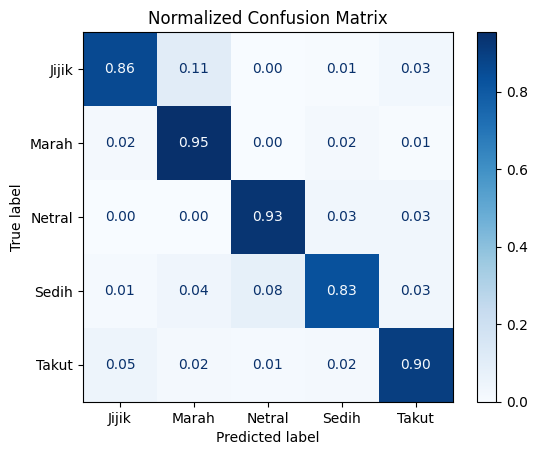

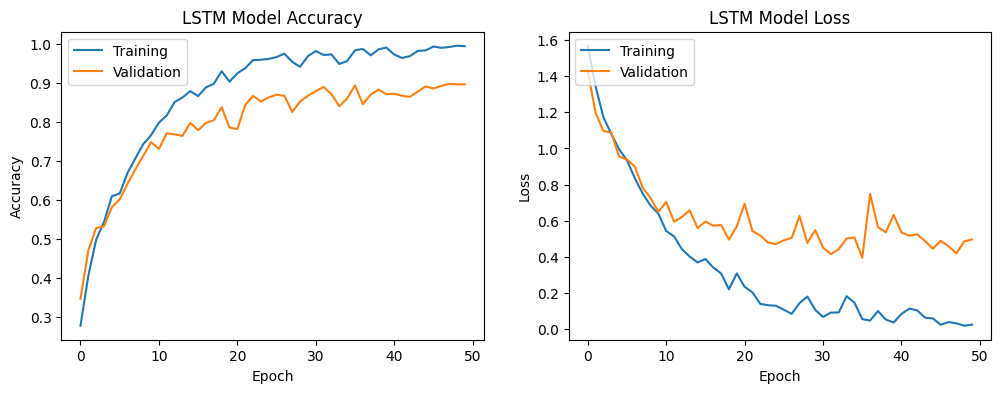

Saved to:  /content/drive/MyDrive/TADATA/Models/LSTMBASIC30/LSTM-SER_SlimModel.h5


In [ ]:
import os, glob, random, warnings
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Masking, LSTM, Bidirectional
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from keras.activations import relu, softmax

warnings.filterwarnings("ignore")
database_path = '/content/drive/MyDrive/TADATA/FinalData/BigData_Filtered'
classes = ['Jijik', 'Marah', 'Netral', 'Sedih', 'Takut']

SR = 16000
WIN_S, HOP_S = 0.025, 0.0125
N_FFT = 512
WIN = int(round(WIN_S * SR))
HOP = int(round(HOP_S * SR))
N_MFCC = 40
N_MELS = 128 # Added N_MELS parameter
PE_COEFF = 0.97
USE_DELTA = False
USE_AUG_NOISE = True
USE_AUG_SHIFT = True
MAX_FRAMES = 400
MASK_VALUE = 0.0
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Data Augmentation
def add_noise(y, noise_factor=0.001):
    if len(y) == 0: return y
    n = np.random.randn(len(y)).astype(np.float32)
    y_n = y + noise_factor*n
    m = np.max(np.abs(y_n)) + 1e-9
    return (y_n/m).astype(np.float32)

def shift_wave(y, sr=SR, shift_sec=0.25, direction='right'):
    if len(y) == 0: return y
    shift = int(shift_sec*sr)
    shift = shift if direction=='right' else -shift
    y_roll = np.roll(y, shift).astype(np.float32)
    return y_roll


# Feature Extraction
def pre_emphasis(y, pe_coeff=PE_COEFF):
    if y.size == 0: return y
    y = y.astype(np.float32)
    return np.append(y[0], y[1:] - pe_coeff*y[:-1]).astype(np.float32)

def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr, mono=True, res_type='kaiser_best')
    return y.astype(np.float32)

# Sequence Features Extraction - Modified to include Chroma and Mel
def extract_feature_seq(y, sr, use_mfcc=True, use_chroma=True, use_mel=True, use_delta=USE_DELTA):
    if len(y) < WIN:
        y = np.pad(y, (0, WIN-len(y)), mode="constant")
    # pre-emphasis
    y = pre_emphasis(y, PE_COEFF)

    # Compute STFT once if needed for multiple features
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window='hamming', center=True)
    mag = np.abs(stft) + 1e-10 # Magnitude for features


    feats = []

    if use_mfcc: # MFCC shape: (n_mfcc, T)
        mfcc = librosa.feature.mfcc(
            y=y, sr=sr, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP, win_length=WIN, window='hamming'
        )
        feats.append(mfcc)

        if use_delta: # Delta and Delta-delta MFCC
            d1 = librosa.feature.delta(mfcc, order=1)
            d2 = librosa.feature.delta(mfcc, order=2)
            feats += [d1, d2]

    if use_chroma: # Chroma shape: (n_chroma, T)
         chroma = librosa.feature.chroma_stft(
            S=mag, sr=sr, n_fft=N_FFT, hop_length=HOP, tuning=None
        )
         feats.append(chroma)

    if use_mel: # Mel-Filter Bank shape: (n_mels, T)
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
            window='hamm', n_mels=N_MELS, power=2.0, fmin=0.0, fmax=sr/2
        )
        mel_db = librosa.power_to_db(mel, ref=1.0)
        feats.append(mel_db)

    min_frames = min(f.shape[1] for f in feats)
    stacked_feats = np.vstack([f[:, :min_frames] for f in feats]).T.astype(np.float32)  # (T, F)


    return stacked_feats


def pad_or_truncate(seq_tf, max_frames=MAX_FRAMES, pad_value=MASK_VALUE):
    T, F = seq_tf.shape
    if T == max_frames:
        return seq_tf
    if T > max_frames:
        return seq_tf[:max_frames, :]
    pad_len = max_frames - T
    pad = np.full((pad_len, F), pad_value, dtype=np.float32)
    return np.vstack([seq_tf, pad])

# ---------- Loader dataset ke format (N, T, F) ----------
def load_dataset_sequences(root_dir, classes, save_numpy=True):
    X_list, y_list = [], []
    n_files, n_err = 0, 0

    for emo in classes:
        emo_dir = os.path.join(root_dir, emo)
        if not os.path.isdir(emo_dir):
            print(f"[WARN] Missing: {emo_dir}")
            continue

        wavs = glob.glob(os.path.join(emo_dir, '**', '*.wav'), recursive=True)
        if not wavs:
            print(f"[WARN] No wav in: {emo_dir}")

        for wav in wavs:
            try:
                y = load_audio(wav, SR)
                # Call extract_feature_seq with all features enabled
                f_seq = extract_feature_seq(y, SR, use_mfcc=True, use_chroma=True, use_mel=True) # (T, F)
                X_list.append(pad_or_truncate(f_seq))      # (MAX_FRAMES, F)
                y_list.append(emo)
                n_files += 1

                # Augmentation : Noise
                if USE_AUG_NOISE:
                    y_n = add_noise(y, 0.001)
                    # Extract features from augmented data
                    f_n = extract_feature_seq(y_n, SR, use_mfcc=True, use_chroma=True, use_mel=True)
                    X_list.append(pad_or_truncate(f_n))
                    y_list.append(emo)

                # Augmentation : Shift
                if USE_AUG_SHIFT:
                    y_s = shift_wave(y, SR, 0.25, 'right')
                     # Extract features from augmented data
                    f_s = extract_feature_seq(y_s, SR, use_mfcc=True, use_chroma=True, use_mel=True)
                    X_list.append(pad_or_truncate(f_s))
                    y_list.append(emo)

            except Exception as e:
                n_err += 1
                print(f"[ERROR] {wav}: {e}")

    X = np.stack(X_list).astype(np.float32)  # (N, T, F)
    y_names = np.array(y_list, dtype=object)

    if save_numpy:
        np.save('X_seq_multi_feat.npy', X) # Changed filename
        np.save('y_seq_multi_feat.npy', y_names) # Changed filename

    print(f"Selesai. File sukses: {n_files}, total sampel (dengan aug): {len(X_list)}, error: {n_err}")
    print("X_seq shape:", X.shape)  # (N, T, F)
    return X, y_names

if USE_DELTA == True:
    print("Extracting sequential multi-features (MFCC ± delta ± delta2, Chroma, Mel) ...") # Updated message
else:
  print("Extracting sequential multi-features (MFCC, Chroma, Mel) ...") # Updated message

X_seq, y_names = load_dataset_sequences(database_path, classes, save_numpy=True)

# Label Encoding
le = LabelEncoder()
y = le.fit_transform(y_names)
n_classes = len(le.classes_)
print("Label map:", dict(zip(le.classes_, range(n_classes))))

# Data Splitting
X_tr, X_te, y_tr, y_te = train_test_split(X_seq, y, test_size=0.2, random_state=SEED, stratify=y)

# Feature Scaling Per-frame
T, F = X_tr.shape[1], X_tr.shape[2]
scaler = StandardScaler(with_mean=True, with_std=True)

Xtr_2d = X_tr.reshape(-1, F)
Xte_2d = X_te.reshape(-1, F)

mask_tr_rows = ~(np.all(np.isclose(Xtr_2d, MASK_VALUE), axis=1))
scaler.fit(Xtr_2d[mask_tr_rows])

X_tr_scaled = scaler.transform(Xtr_2d).reshape(-1, T, F)
X_te_scaled = scaler.transform(Xte_2d).reshape(-1, T, F)

y_tr_cat = to_categorical(y_tr, num_classes=n_classes)
y_te_cat = to_categorical(y_te, num_classes=n_classes)

# LSTM Modeling
model_name = "LSTM-SER_Balance_MultiFeat" # Updated model name
def build_lstm_model(timesteps=T, featdim=F, n_classes=n_classes, bidir=True):
    m = Sequential()
    m.add(Masking(mask_value=MASK_VALUE, input_shape=(timesteps, featdim)))
    if bidir:
        m.add(Bidirectional(LSTM(128, return_sequences=True)))
        m.add(Dropout(0.3))
        m.add(Bidirectional(LSTM(64)))
    else:
        m.add(LSTM(128, return_sequences=True))
        m.add(Dropout(0.3))
        m.add(LSTM(64))
    m.add(Dropout(0.3))
    m.add(Dense(64, activation=relu)) # Use the imported relu
    m.add(Dropout(0.3))
    m.add(Dense(n_classes, activation=softmax)) # Use the imported softmax

    m.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

model = build_lstm_model()

model.summary()


# Train the Model
history = model.fit(
    X_tr_scaled, y_tr_cat,
    validation_data=(X_te_scaled, y_te_cat),
    epochs=50,
    batch_size=64,
    verbose=1
)

# Model Evaluation
y_pred_prob = model.predict(X_te_scaled, batch_size=64)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=le.classes_, digits=4))

print("Confusion Matrix:")
# 1. UBAH DI SINI: Tambahkan normalize='true'
cm = confusion_matrix(y_te, y_pred, normalize='true')
print(cm)

# ========================================================
# TAMBAHAN: Menampilkan visualisasi Confusion Matrix
# ========================================================
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
# 2. UBAH DI SINI: Ganti values_format='d' menjadi values_format='.2f'
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('Normalized Confusion Matrix') # (Opsional) Judul disesuaikan
plt.show()
# ========================================================

# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('LSTM Model Accuracy'); plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('LSTM Model Loss'); plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

plt.show()

# Save Model
os.makedirs('/content/drive/MyDrive/TADATA/Models/LSTMBASIC30', exist_ok=True)
save_path = '/content/drive/MyDrive/TADATA/Models/LSTMBASIC30/LSTM-SER_SlimModel.h5'
model.save(save_path)
print("Saved to: ", save_path)